In [16]:
import sys
sys.executable


'c:\\Users\\VIOLLETTE MONCHARI\\.conda\\envs\\dsml\\python.exe'

In [17]:
import pandas as pd
import numpy as np
print(pd.__version__, np.__version__)

2.3.3 2.3.5


In [18]:
import pandas as pd

#Loading Data
file_path = "../data/raw/online_retail_raw.xlsx"
df = pd.read_excel(file_path)

#Checking
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (541909, 8)
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [19]:
#chacking for types
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

In [20]:
#checking for missing values
df.isna() .sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [21]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [22]:
#Check negative quantities
df[df["Quantity"] <= 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [23]:
#Check Negative Prices 
df[df["UnitPrice"] <=0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom


In [24]:
#Count Invalid Rows
invalid_quantity = (df["Quantity"] <= 0).sum()
invalid_price = (df["UnitPrice"] <= 0).sum()

invalid_quantity, invalid_price

(np.int64(10624), np.int64(2517))

In [25]:
#Keep only valid sales
df_clean = df.loc[
    (df["Quantity"] >0) & (df["UnitPrice"] > 0)
].copy()

df_clean.shape

(530104, 8)

In [26]:
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,530104.000000,530104,530104.000000,397884.000000
mean,10.542037,2011-07-04 20:16:05.225087744,3.907625,15294.423453
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,1.000000,2011-03-28 12:22:00,1.250000,13969.000000
50%,3.000000,2011-07-20 12:58:00,2.080000,15159.000000
75%,10.000000,2011-10-19 12:39:00,4.130000,16795.000000
max,80995.000000,2011-12-09 12:50:00,13541.330000,18287.000000
std,155.524124,NaN,35.915681,1713.141560


In [27]:
#Save Clean Dataset
clean_path = "../data/cleaned/online_retail_cleaned.csv"
df_clean.to_csv(clean_path, index=False)

In [28]:
df_clean["LineRevenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]
df_clean[["Quantity", "UnitPrice", "LineRevenue"]].head()

,Quantity,UnitPrice,LineRevenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [29]:
#Create Invoice Summary Table
invoice_summary = (
    df_clean.groupby ("InvoiceNo", as_index=False)
    .agg(
        InvoiceDate= ("InvoiceDate", "min"),
        CustomerID= ("CustomerID", "first"),
        Country= ("Country", "first"),
        InvoiceRevenue= ("LineRevenue", "sum"),
        Lines= ("InvoiceNo", "count")
    )
)
invoice_summary.head()

,InvoiceNo,InvoiceDate,CustomerID,Country,InvoiceRevenue,Lines
0,536365,2010-12-01 08:26:00,17850.0,United Kingdom,139.12,7
1,536366,2010-12-01 08:28:00,17850.0,United Kingdom,22.20,2
2,536367,2010-12-01 08:34:00,13047.0,United Kingdom,278.73,12
3,536368,2010-12-01 08:34:00,13047.0,United Kingdom,70.05,4
4,536369,2010-12-01 08:35:00,13047.0,United Kingdom,17.85,1


In [30]:
#Create Customer Summary Table
customer_summary = (
    invoice_summary.dropna(subset=["CustomerID"])
    .groupby("CustomerID", as_index=False)
    .agg(
        TotalRevenue=("InvoiceRevenue", "sum"),
        NumInvoices=("InvoiceNo", "nunique"),
        FirstPurchase=("InvoiceDate", "min"),
        LastPurchase=("InvoiceDate", "max")
    )
)

customer_summary.sort_values("TotalRevenue", ascending=False).head(10)

,CustomerID,TotalRevenue,NumInvoices,FirstPurchase,LastPurchase
1689,14646.0,280206.02,73,2010-12-20 10:09:00,2011-12-08 12:12:00
4201,18102.0,259657.30,60,2010-12-07 16:42:00,2011-12-09 11:50:00
3728,17450.0,194550.79,46,2010-12-07 09:23:00,2011-12-01 13:29:00
3008,16446.0,168472.50,2,2011-05-18 09:52:00,2011-12-09 09:15:00
1879,14911.0,143825.06,201,2010-12-01 14:05:00,2011-12-08 15:54:00
55,12415.0,124914.53,21,2011-01-06 11:12:00,2011-11-15 14:22:00
1333,14156.0,117379.63,55,2010-12-03 11:48:00,2011-11-30 10:54:00
3771,17511.0,91062.38,31,2010-12-01 10:19:00,2011-12-07 10:12:00
2702,16029.0,81024.84,63,2010-12-01 09:57:00,2011-11-01 10:27:00
0,12346.0,77183.60,1,2011-01-18 10:01:00,2011-01-18 10:01:00


In [31]:
#Save Outputs

df_clean.to_csv("../data/cleaned/online_retail_cleaned.csv", index=False)
invoice_summary.to_csv("../data/cleaned/invoice_summary.csv", index=False)
customer_summary.to_csv("../data/cleaned/customer_summary.csv", index=False)

In [32]:
df_clean.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'LineRevenue'],
      dtype='object')

In [ ]:
#Viewing the top customer
customer_summary.sort_values("TotalRevenue", ascending=False).head(10)

,CustomerID,TotalRevenue,NumInvoices,FirstPurchase,LastPurchase
1689,14646.0,280206.02,73,2010-12-20 10:09:00,2011-12-08 12:12:00
4201,18102.0,259657.30,60,2010-12-07 16:42:00,2011-12-09 11:50:00
3728,17450.0,194550.79,46,2010-12-07 09:23:00,2011-12-01 13:29:00
3008,16446.0,168472.50,2,2011-05-18 09:52:00,2011-12-09 09:15:00
1879,14911.0,143825.06,201,2010-12-01 14:05:00,2011-12-08 15:54:00
55,12415.0,124914.53,21,2011-01-06 11:12:00,2011-11-15 14:22:00
1333,14156.0,117379.63,55,2010-12-03 11:48:00,2011-11-30 10:54:00
3771,17511.0,91062.38,31,2010-12-01 10:19:00,2011-12-07 10:12:00
2702,16029.0,81024.84,63,2010-12-01 09:57:00,2011-11-01 10:27:00
0,12346.0,77183.60,1,2011-01-18 10:01:00,2011-01-18 10:01:00


In [ ]:
#Asigned the top customers to a variable top_customers

top_customers = customer_summary.sort_values("TotalRevenue", ascending=False).head(10)

top_customers

,CustomerID,TotalRevenue,NumInvoices,FirstPurchase,LastPurchase
1689,14646.0,280206.02,73,2010-12-20 10:09:00,2011-12-08 12:12:00
4201,18102.0,259657.30,60,2010-12-07 16:42:00,2011-12-09 11:50:00
3728,17450.0,194550.79,46,2010-12-07 09:23:00,2011-12-01 13:29:00
3008,16446.0,168472.50,2,2011-05-18 09:52:00,2011-12-09 09:15:00
1879,14911.0,143825.06,201,2010-12-01 14:05:00,2011-12-08 15:54:00
55,12415.0,124914.53,21,2011-01-06 11:12:00,2011-11-15 14:22:00
1333,14156.0,117379.63,55,2010-12-03 11:48:00,2011-11-30 10:54:00
3771,17511.0,91062.38,31,2010-12-01 10:19:00,2011-12-07 10:12:00
2702,16029.0,81024.84,63,2010-12-01 09:57:00,2011-11-01 10:27:00
0,12346.0,77183.60,1,2011-01-18 10:01:00,2011-01-18 10:01:00


In [35]:
#Checking the Customer Summary

customer_summary["TotalRevenue"].describe()

count      4338.000000
mean       2054.266460
std        8989.230441
min           3.750000
25%         307.415000
50%         674.485000
75%        1661.740000
max      280206.020000
Name: TotalRevenue, dtype: float64

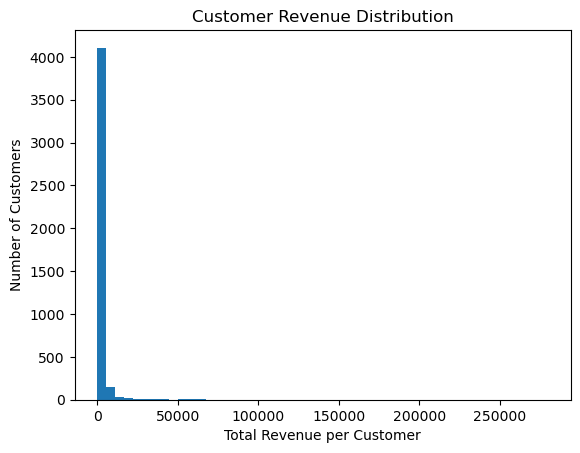

In [37]:
#Simple Revenue Histogram

import matplotlib.pyplot as plt

plt.hist(customer_summary["TotalRevenue"], bins=50)
plt.xlabel("Total Revenue per Customer")
plt.ylabel("Number of Customers")
plt.title ("Customer Revenue Distribution")
plt.show()

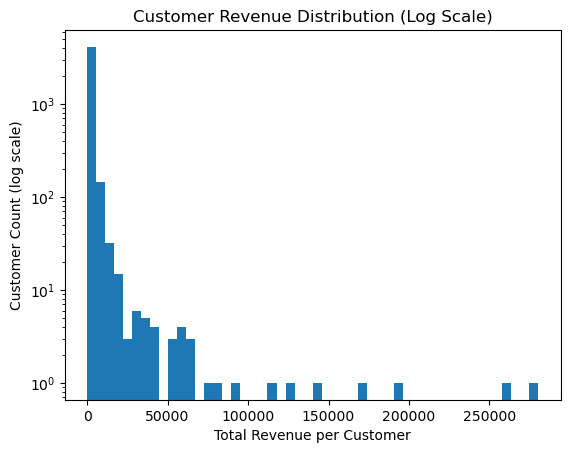

In [38]:
#Log scale to make it more visible

plt.hist(customer_summary["TotalRevenue"], bins=50, log=True)
plt.xlabel("Total Revenue per Customer")
plt.ylabel("Customer Count (log scale)")
plt.title("Customer Revenue Distribution (Log Scale)")
plt.show()

In [39]:
#How big are Invoices

invoice_summary["InvoiceRevenue"].describe()

count     19960.000000
mean        534.403033
std        1780.487648
min           0.380000
25%         152.510000
50%         303.835000
75%         495.615000
max      168469.600000
Name: InvoiceRevenue, dtype: float64

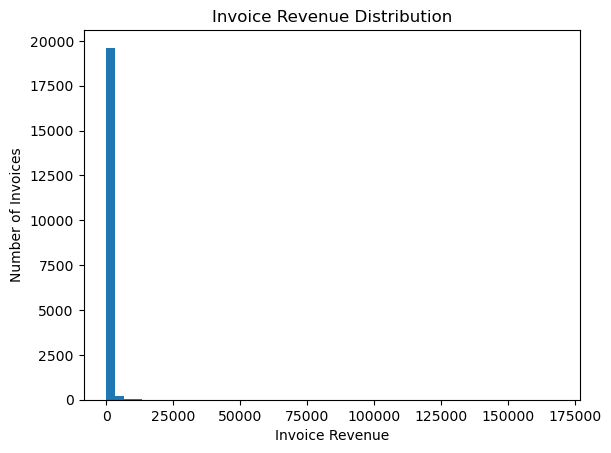

In [40]:
# Visual for how big invoices are

plt.hist(invoice_summary["InvoiceRevenue"], bins=50)
plt.xlabel("Invoice Revenue")
plt.ylabel("Number of Invoices")
plt.title("Invoice Revenue Distribution")
plt.show()

In [41]:
#Lines per Invoice

invoice_summary["Lines"].describe()

count    19960.000000
mean        26.558317
std         47.542066
min          1.000000
25%          6.000000
50%         15.000000
75%         29.000000
max       1114.000000
Name: Lines, dtype: float64

In [43]:
#Where does most revenue come from in terms of country

country_revenue = (
    df_clean
    .groupby("Country", as_index=False)["LineRevenue"]
    .sum()
    .sort_values("LineRevenue", ascending=False)
)

#Check

country_revenue.head(10)

,Country,LineRevenue
36,United Kingdom,9025222.084
24,Netherlands,285446.340
10,EIRE,283453.960
14,Germany,228867.140
13,France,209715.110
0,Australia,138521.310
31,Spain,61577.110
33,Switzerland,57089.900
3,Belgium,41196.340
32,Sweden,38378.330


In [44]:
#Do a few customers generate most revenue?

customer_summary["RevenueShare"] = (
    customer_summary["TotalRevenue"] /
    customer_summary["TotalRevenue"].sum()
)

#Check

customer_summary.sort_values(
    "RevenueShare", ascending=False
).head(10)

,CustomerID,TotalRevenue,NumInvoices,FirstPurchase,LastPurchase,RevenueShare
1689,14646.0,280206.02,73,2010-12-20 10:09:00,2011-12-08 12:12:00,0.031444
4201,18102.0,259657.30,60,2010-12-07 16:42:00,2011-12-09 11:50:00,0.029138
3728,17450.0,194550.79,46,2010-12-07 09:23:00,2011-12-01 13:29:00,0.021832
3008,16446.0,168472.50,2,2011-05-18 09:52:00,2011-12-09 09:15:00,0.018905
1879,14911.0,143825.06,201,2010-12-01 14:05:00,2011-12-08 15:54:00,0.016139
55,12415.0,124914.53,21,2011-01-06 11:12:00,2011-11-15 14:22:00,0.014017
1333,14156.0,117379.63,55,2010-12-03 11:48:00,2011-11-30 10:54:00,0.013172
3771,17511.0,91062.38,31,2010-12-01 10:19:00,2011-12-07 10:12:00,0.010219
2702,16029.0,81024.84,63,2010-12-01 09:57:00,2011-11-01 10:27:00,0.009092
0,12346.0,77183.60,1,2011-01-18 10:01:00,2011-01-18 10:01:00,0.008661


In [45]:
#How many customers are one time buyers

one_time_customers = customer_summary[
    customer_summary["NumInvoices"] == 1
]

len(one_time_customers)

1493

In [46]:
#Average revenue per invoice

invoice_summary["InvoiceRevenue"].mean()

np.float64(534.403033266533)